In [80]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir("/Users/thomasmaisch/Desktop/Alles/BGG_Project/bgg-data-analysis")


,id,name,minplayers,maxplayers,minplaytime,maxplaytime,minage,usersrated,average,bayesaverage,complexity,yearpublished
0,13,Catan,3,4,60,120,10,142781,7.09040,6.90249,2.2816,1995
1,822,Carcassonne,2,5,30,45,7,140178,7.41660,7.29878,1.8846,2000
2,30549,Pandemic,2,4,45,45,8,135383,7.51287,7.40339,2.3939,2008
3,167791,Terraforming Mars,1,5,120,120,12,113682,8.33408,8.18309,3.2728,2016
4,266192,Wingspan,1,5,40,70,10,113544,7.99763,7.84451,2.4810,2019


In [ ]:
df = pd.read_csv('boardgames_ranks.csv')
df_filtered = df[df['is_expansion'] == 0]
df_filtered = df_filtered.sort_values('usersrated', ascending=False)
df_top5000 = df_filtered.head(5000)

print(df_top5000.shape)
print(df_top5000[['id', 'name', 'usersrated', 'rank']].head(10))

In [ ]:
df_top5000.to_csv("top5000_games.csv", index=False)

In [ ]:
import requests
import time
from dotenv import load_dotenv
import os
import xml.etree.ElementTree as ET

load_dotenv()
token = os.getenv("BGG_TOKEN")
headers = {"Authorization": f"Bearer {token}"}

def parse_block(xml_text):
    root = ET.fromstring(xml_text)
    games = []
    for item in root.findall("item"):
        game = {}
        game["id"] = item.get("id")
        game["name"] = item.find("name[@type='primary']").get("value")
        game["yearpublished"] = item.findtext("yearpublished")
        game["minplayers"] = item.find("minplayers").get("value")
        game["maxplayers"] = item.find("maxplayers").get("value")
        game["minplaytime"] = item.find("minplaytime").get("value")
        game["maxplaytime"] = item.find("maxplaytime").get("value")
        game["minage"] = item.find("minage").get("value")
        stats = item.find("statistics/ratings")
        game["usersrated"] = stats.find("usersrated").get("value")
        game["average"] = stats.find("average").get("value")
        game["bayesaverage"] = stats.find("bayesaverage").get("value")
        game["complexity"] = stats.find("averageweight").get("value")
        games.append(game)
    return games

ids = df_top5000["id"].astype(str).tolist()
blocks = [ids[i:i+20] for i in range(0, len(ids), 20)]

all_games = []
for i, block in enumerate(blocks):
    url = f"https://boardgamegeek.com/xmlapi2/thing?id={','.join(block)}&type=boardgame&stats=1"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        games = parse_block(response.text)
        all_games.extend(games)
        print(f"Block {i+1}/{len(blocks)} ✓ ({len(all_games)} Spiele)")
    else:
        print(f"Block {i+1} Fehler: {response.status_code}")
    
    time.sleep(3)

df_games = pd.DataFrame(all_games)
df_games.to_csv("bgg_raw_data.csv", index=False)
print("Fertig!")


In [ ]:
df_games.to_csv("bgg_raw_data.csv", index=False)

In [ ]:
df = pd.read_csv("bgg_raw_data.csv")
df.head()

In [82]:
df_top5000 = pd.read_csv("top5000_games.csv")

df_top5000["id"] = df_top5000["id"].astype(str)
df = df.drop(columns=['yearpublished'])
df["id"] = df["id"].astype(str)
df = df.merge(df_top5000[["id", "yearpublished"]], on="id", how="left")
df.head()

,id,name,minplayers,maxplayers,minplaytime,maxplaytime,minage,usersrated,average,bayesaverage,complexity,yearpublished
0,13,Catan,3,4,60,120,10,142781,7.09040,6.90249,2.2816,1995
1,822,Carcassonne,2,5,30,45,7,140178,7.41660,7.29878,1.8846,2000
2,30549,Pandemic,2,4,45,45,8,135383,7.51287,7.40339,2.3939,2008
3,167791,Terraforming Mars,1,5,120,120,12,113682,8.33408,8.18309,3.2728,2016
4,266192,Wingspan,1,5,40,70,10,113544,7.99763,7.84451,2.4810,2019


In [81]:
df = df.replace("", np.nan)

print(df.isna().mean())

id               0.0
name             0.0
minplayers       0.0
maxplayers       0.0
minplaytime      0.0
maxplaytime      0.0
minage           0.0
usersrated       0.0
average          0.0
bayesaverage     0.0
complexity       0.0
yearpublished    0.0
dtype: float64


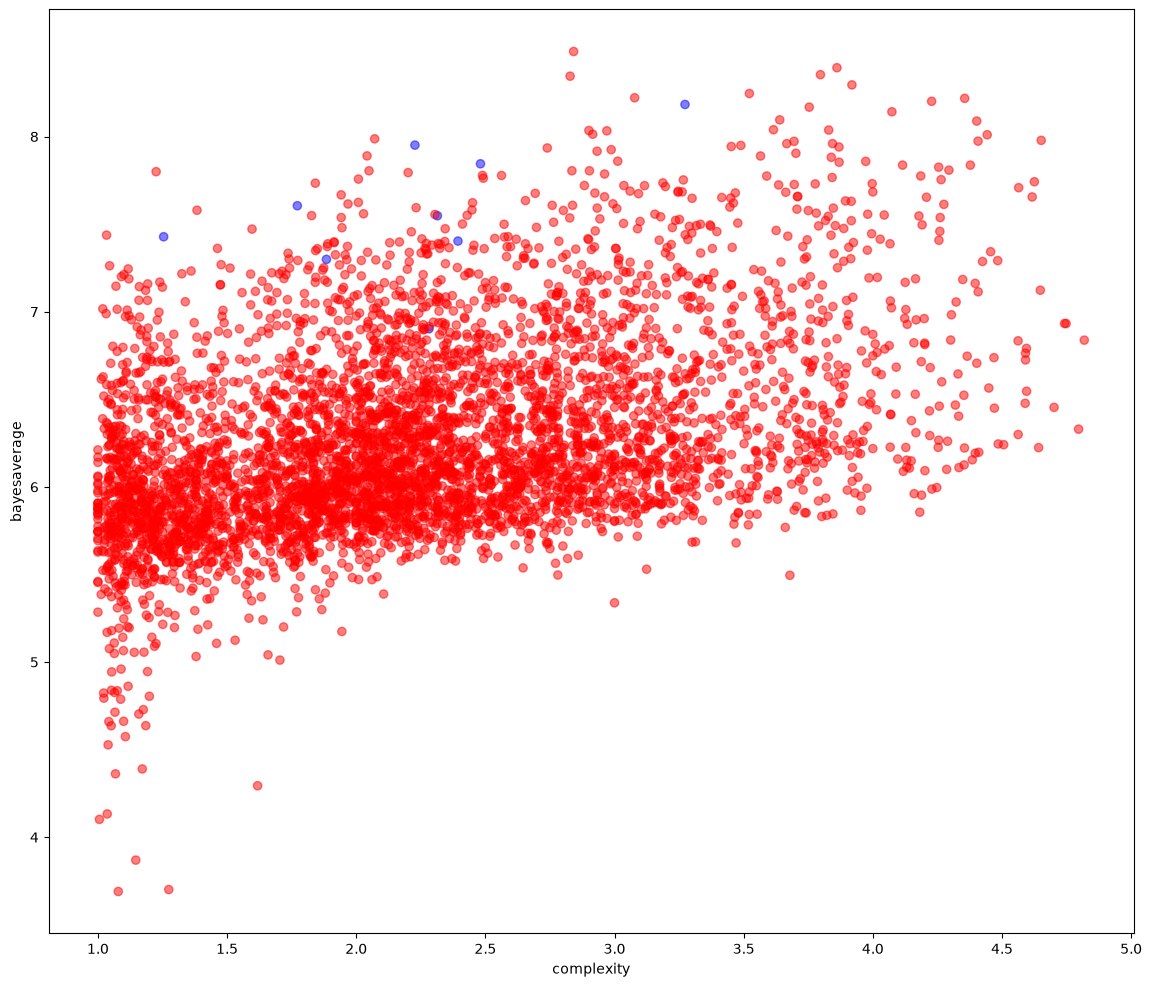

In [31]:
colors = df['usersrated'].apply(lambda x: 'blue' if x >= 100000 else 'red')


plt.figure(figsize=(14,12))
plt.scatter(df['complexity'], df['bayesaverage'], c = colors, alpha=0.5)
plt.ylabel('bayesaverage')
plt.xlabel('complexity')
plt.show();

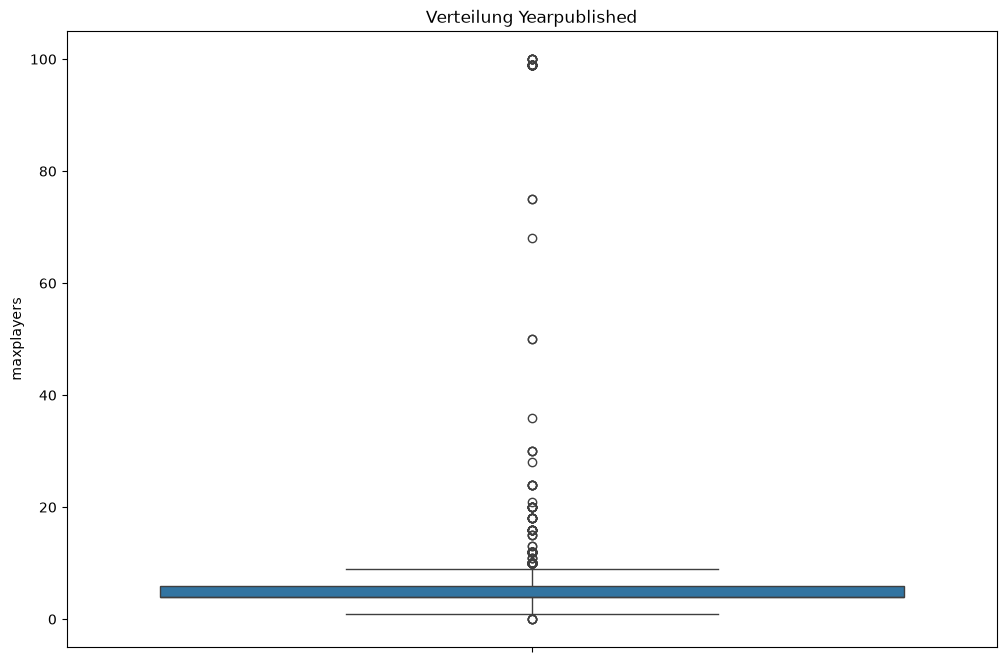

In [86]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.boxplot(y=df['maxplayers'])
plt.title('Verteilung Yearpublished')
plt.show()

In [49]:
num_cols = ['minplayers', 'maxplayers', 'minplaytime', 'maxplaytime', 'minage', 'usersrated', 'average', 'bayesaverage', 'complexity']

df[num_cols] = df[num_cols].astype(float)

In [50]:
df.describe()

,minplayers,maxplayers,minplaytime,maxplaytime,minage,usersrated,average,bayesaverage,complexity,yearpublished
count,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,1.862000,5.47900,50.582200,76.36960,10.732400,5079.884400,6.983714,6.262329,2.238500,2000.93340
std,0.715163,8.08667,44.861031,206.40876,2.681684,9770.501732,0.693650,0.533913,0.802301,180.17408
min,0.000000,0.00000,0.000000,0.00000,0.000000,818.000000,2.422530,3.689980,1.000000,-3500.00000
25%,1.000000,4.00000,30.000000,30.00000,8.000000,1225.000000,6.585978,5.899185,1.634250,2008.00000
50%,2.000000,4.00000,40.000000,60.00000,10.000000,2043.000000,7.012610,6.153360,2.153800,2015.00000
75%,2.000000,6.00000,60.000000,90.00000,13.000000,4427.000000,7.433295,6.544437,2.768825,2020.00000
max,8.000000,100.00000,720.000000,12000.00000,21.000000,142781.000000,9.141980,8.485540,4.818600,2027.00000


In [83]:
print('minplayers == 0:', (df['minplayers'] == 0).sum())
print('minplayers > 6:', (df['minplayers'] > 6).sum())
print('maxplayers == 0:', (df['maxplayers'] == 0).sum())
print('maxplayers > 20:', (df['maxplayers'] > 20).sum())
print('minplaytime == 0:', (df['minplaytime'] == 0).sum())
print('maxplaytime > 600:', (df['maxplaytime'] > 600).sum())
print('yearpublished < 1900:', (df['yearpublished'] < 1900).sum())
print('yearpublished > 2026:', (df['yearpublished'] > 2026).sum())


minplayers == 0: 2
minplayers > 6: 4
maxplayers == 0: 4
maxplayers > 20: 48
minplaytime == 0: 7
maxplaytime > 600: 15
yearpublished < 1900: 47
yearpublished > 2026: 1


In [87]:
df = df.loc[
    (df['yearpublished']>=1900) & 
    (df['yearpublished']<=2026) &
    (df['minplayers'] != 0) &
    (df['maxplayers'] != 0) &
    (df['minplaytime'] != 0) &
    (df['maxplaytime'] <= 600)
    ]
len(df)

4931

In [88]:
df.to_csv('bgg_clean_data.csv', index=False)

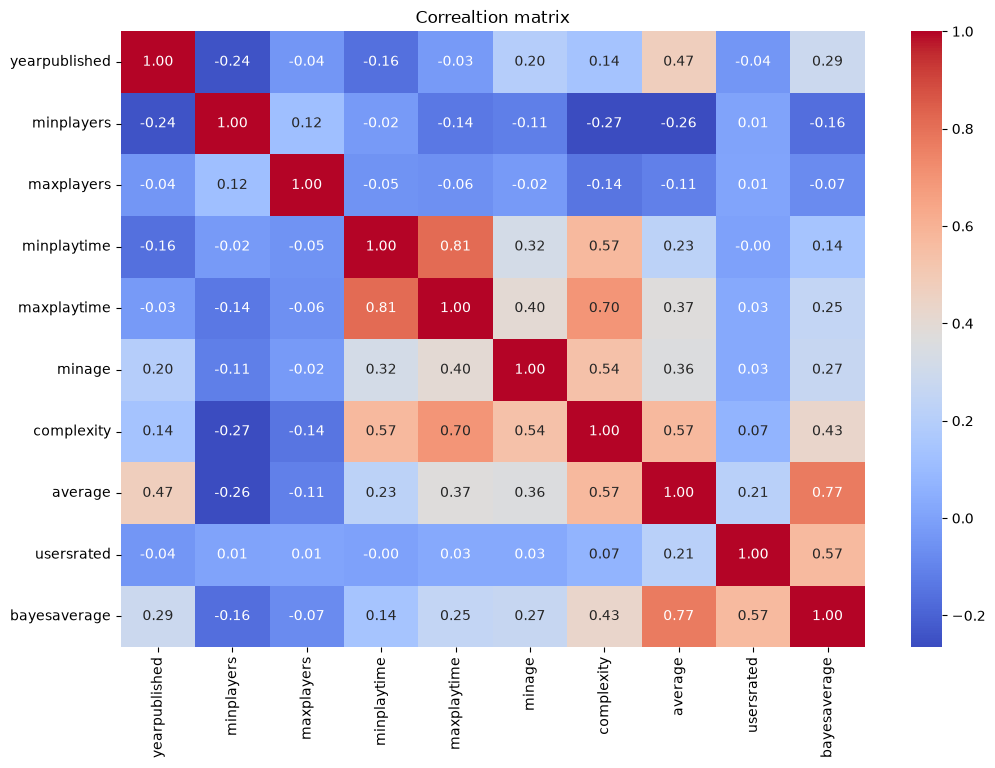

In [96]:
df = pd.read_csv('bgg_clean_data.csv')
df = df[['yearpublished', 'minplayers', 'maxplayers', 'minplaytime', 'maxplaytime', 'minage', 'complexity', 'average', 'usersrated','bayesaverage']]
corr = df.corr(numeric_only=True)
plt.figure(figsize = (12,8))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Correaltion matrix')
plt.show();

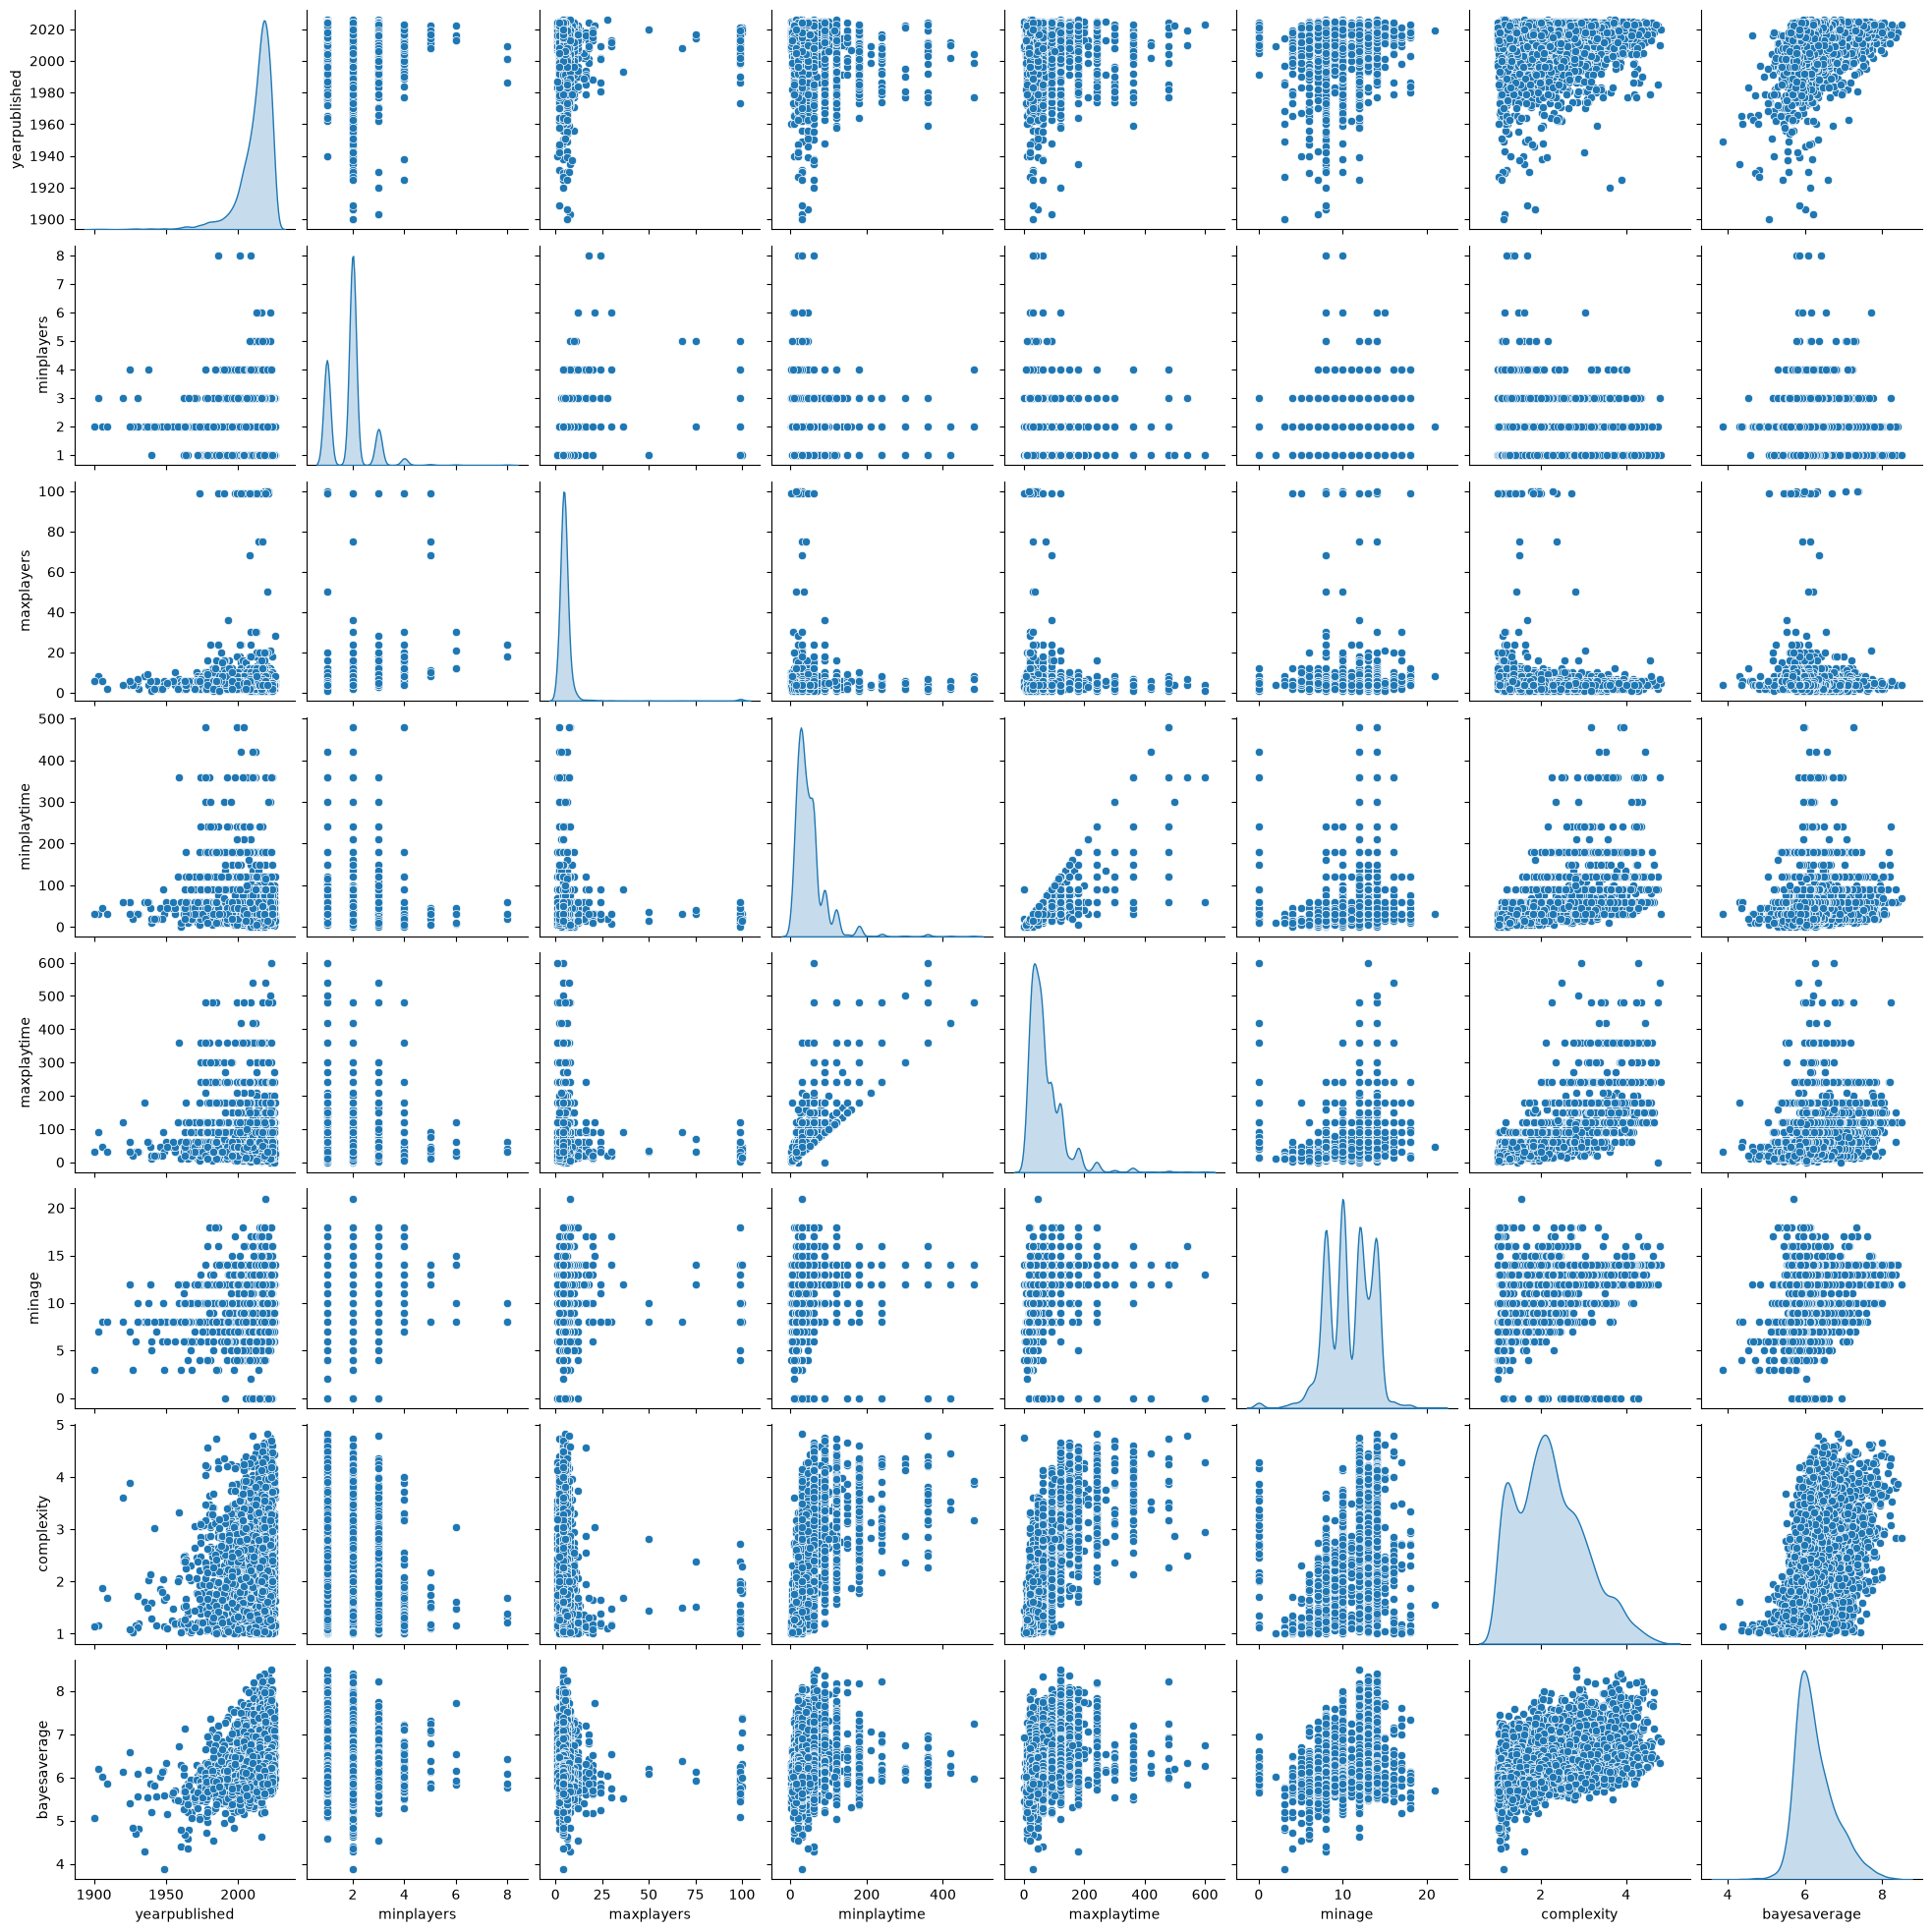

In [98]:
df=df.drop(columns=['average', 'usersrated'])
sns.pairplot(df, diag_kind='kde')

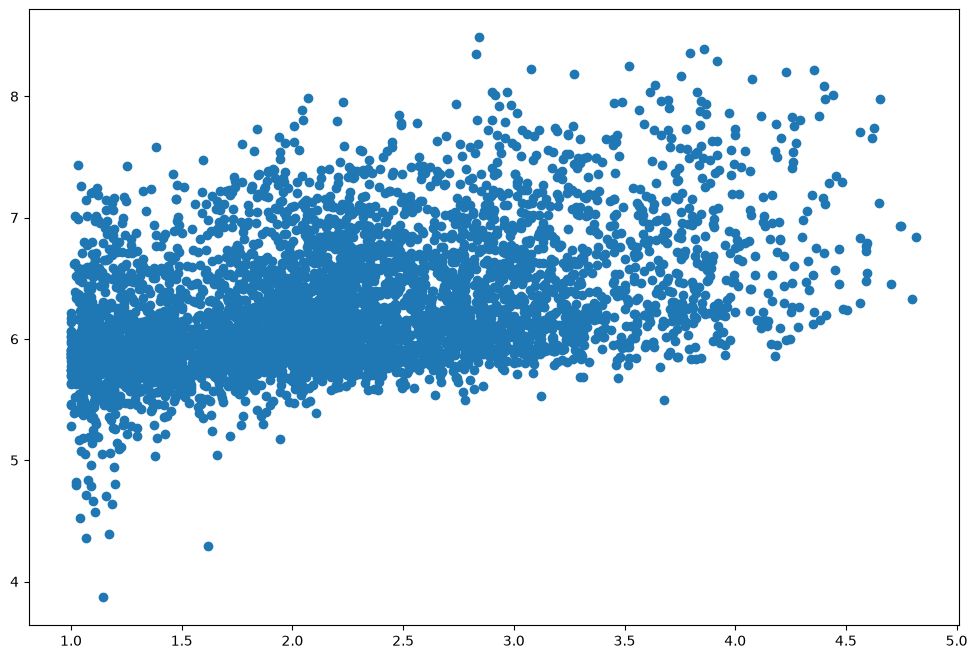

In [101]:
plt.figure(figsize=(12,8))
plt.scatter('complexity', 'bayesaverage', data=df)
plt.show()

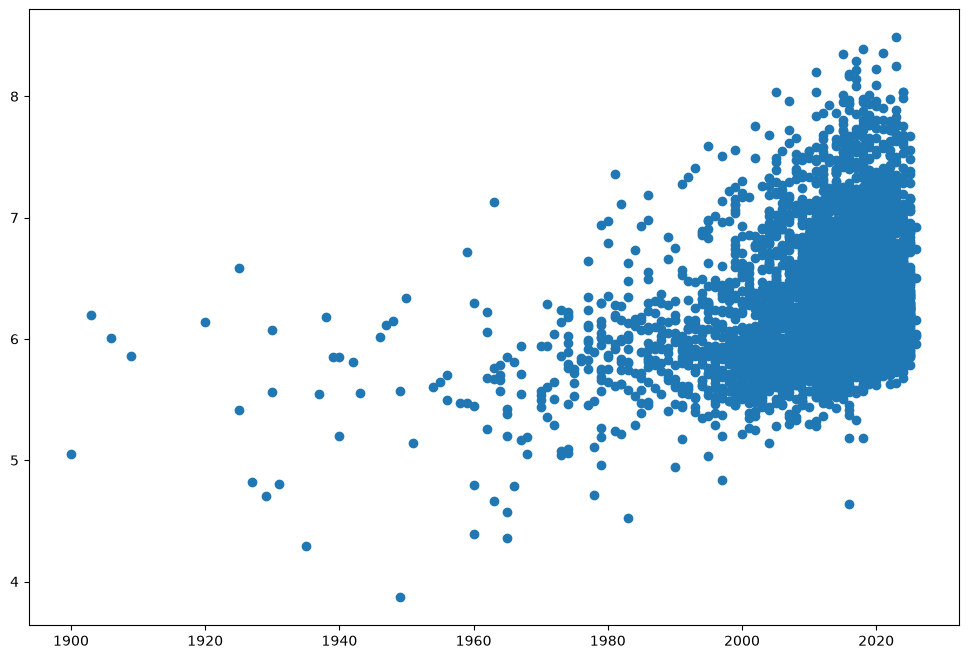

In [102]:
plt.figure(figsize=(12,8))
plt.scatter('yearpublished', 'bayesaverage', data=df)
plt.show()

In [176]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, SelectFromModel, f_regression, mutual_info_regression, RFE, RFECV
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [103]:
X = df.drop(columns='bayesaverage')
y = df['bayesaverage']

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=161)

In [174]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

Index(['yearpublished', 'maxplaytime', 'minage', 'complexity'], dtype='str')


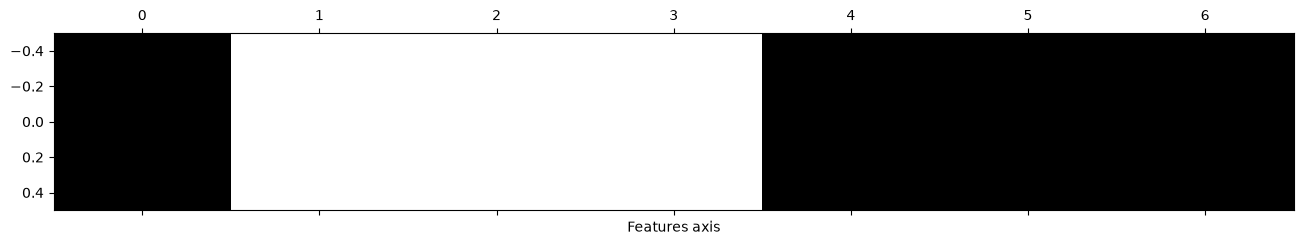

In [161]:
sel = SelectKBest(score_func = mutual_info_regression, k = 4)
sel.fit(X_train, y_train)
KB_mask = sel.get_support()
plt.matshow(KB_mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Features axis');

KB_selected_features = X.columns[KB_mask]
print(KB_selected_features)

In [163]:
lasso = Lasso(alpha = 0.01)
select = SelectFromModel(estimator= lasso, threshold= 1e-10)
select.fit(X_train, y_train)
lasso_mask = select.get_support()
lasso_selected_features = X.columns[lasso_mask]
print(lasso_selected_features)

Index(['yearpublished', 'maxplayers', 'minplaytime', 'complexity'], dtype='str')


In [164]:
rf = RandomForestRegressor()
select = SelectFromModel(estimator= rf, threshold= 1e-10)
select.fit(X_train, y_train)
rf_mask = select.get_support()
rf_selected_features = X.columns[rf_mask]
print(rf_selected_features)



Index(['yearpublished', 'minplayers', 'maxplayers', 'minplaytime',
       'maxplaytime', 'minage', 'complexity'],
      dtype='str')


In [136]:
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

complexity       0.460649
yearpublished    0.193138
maxplaytime      0.085082
minplaytime      0.081184
minage           0.073301
maxplayers       0.070322
minplayers       0.036324
dtype: float64


In [153]:
crossval = KFold(n_splits = 5, random_state = 161, shuffle = True)
lm = LinearRegression()
rfecv_lm = RFECV(estimator = lm, cv = crossval, step= 1)
rfecv_lm.fit(X_train, y_train)
lr_mask = rfecv_lm.get_support()


In [146]:
lm_wr_selected_features = X.columns[rfecv_lm.support_]
print(lm_wr_selected_features)

Index(['yearpublished', 'minplaytime', 'complexity'], dtype='str')


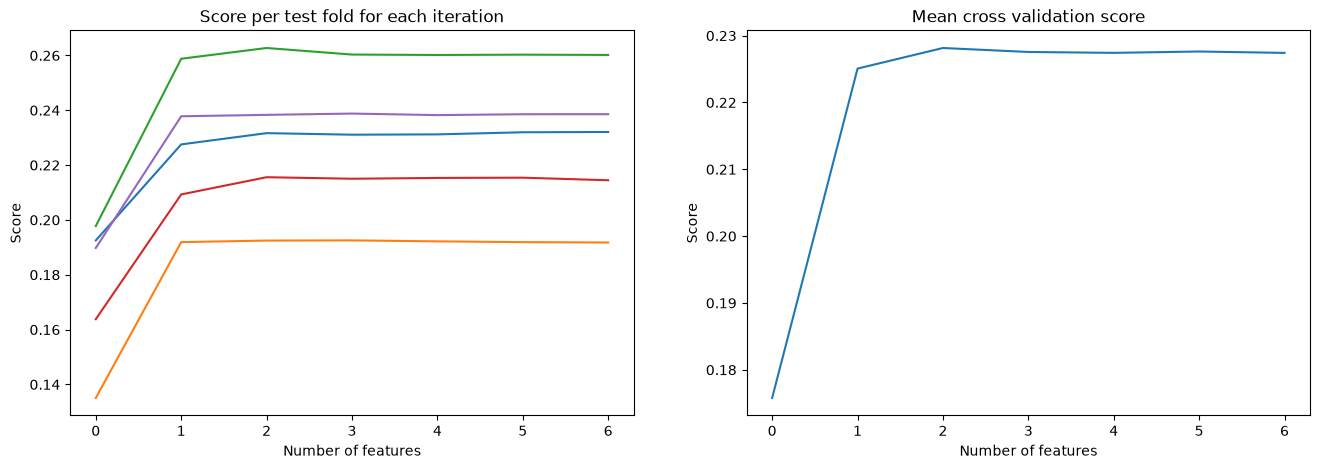

Number of features selected : 3


In [165]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for i in range(5):
    ax1.plot(rfecv_lm.cv_results_[f'split{i}_test_score'])
ax1.set_xlabel('Number of features')
ax1.set_ylabel('Score')
ax1.set_title('Score per test fold for each iteration')
    
ax2.plot(rfecv_lm.cv_results_['mean_test_score'])
ax2.set_xlabel('Number of features')
ax2.set_ylabel('Score')
ax2.set_title('Mean cross validation score')

plt.show();

print("Number of features selected :", rfecv_lm.n_features_)

In [154]:
crossval = KFold(n_splits = 5, random_state = 161, shuffle = True)
rf = RandomForestRegressor()
rfecv = RFECV(estimator = rf, cv = crossval, step= 1)
rfecv.fit(X_train, y_train)
rf_wr_mask = rfecv.get_support()

In [147]:
rf_wr_selected_features = X.columns[rfecv.support_]
print(rf_wr_selected_features)

Index(['yearpublished', 'maxplayers', 'minplaytime', 'maxplaytime', 'minage',
       'complexity'],
      dtype='str')


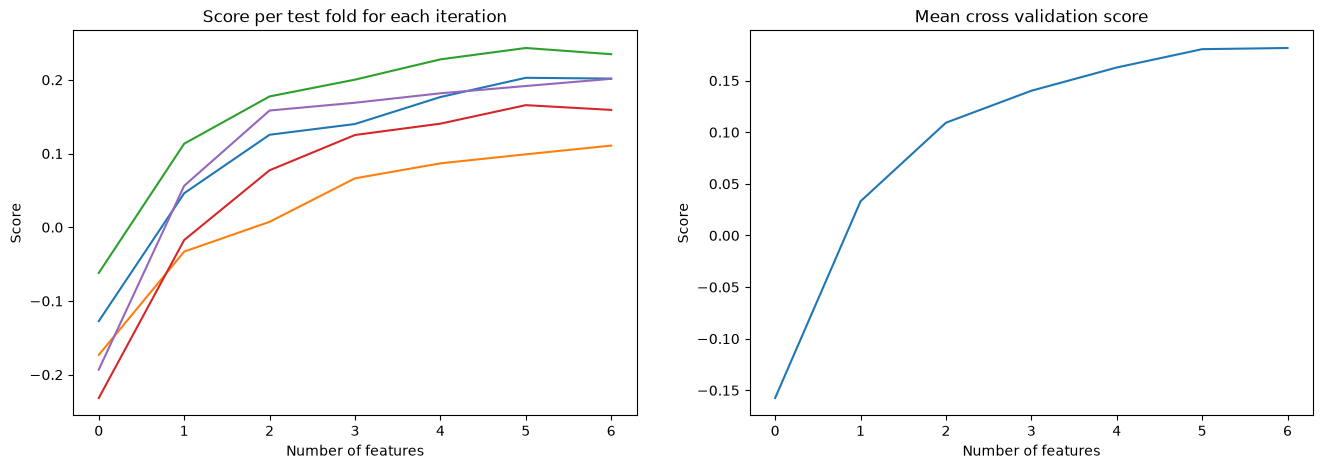

Number of features selected : 7


In [166]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for i in range(5):
    ax1.plot(rfecv.cv_results_[f'split{i}_test_score'])
ax1.set_xlabel('Number of features')
ax1.set_ylabel('Score')
ax1.set_title('Score per test fold for each iteration')
    
ax2.plot(rfecv.cv_results_['mean_test_score'])
ax2.set_xlabel('Number of features')
ax2.set_ylabel('Score')
ax2.set_title('Mean cross validation score')

plt.show();

print("Number of features selected :", rfecv.n_features_)

In [157]:
data = {
    'SelectKBest': KB_mask,
    'Lasso_embedded': lasso_mask,
    'RandomForest_embedded': rf_mask,
    'LinearRegression_wrapper': lr_mask,
    'RandomForest_wrapper': rf_wr_mask
}

df_features = pd.DataFrame(data, index = X.columns)

In [170]:
df_features.head(7)

,SelectKBest,Lasso_embedded,RandomForest_embedded,LinearRegression_wrapper,RandomForest_wrapper
yearpublished,True,True,True,True,True
minplayers,False,False,True,False,True
maxplayers,False,True,True,False,True
minplaytime,False,True,True,True,True
maxplaytime,True,False,True,False,True
minage,True,False,True,False,True
complexity,True,True,True,True,True


In [175]:
X_train_selected = X_train[['minplaytime', 'yearpublished', 'complexity']]
X_test_selected = X_test[['minplaytime', 'yearpublished', 'complexity']]

In [206]:
lm = LinearRegression()
lm.fit(X_train_selected, y_train)
y_predicted = lm.predict((X_test_selected))
lm_results = {'R_squared': r2_score(y_true=y_test, y_pred= y_predicted),
              'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
              'RMSE':root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
              'model': 'LinearRegression'}
print(f'The R sqaured score is: {r2_score(y_true=y_test, y_pred= y_predicted)}')
print(f'The mean absolut error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean sqaured error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')


The R sqaured score is: 0.27182578066623486
The mean absolut error is: 0.37463254576097477
The root mean sqaured error is: 0.47614162993882764


In [207]:
lasso = Lasso(alpha = 0.01)
lasso.fit(X_train_selected, y_train)
y_predicted = lasso.predict((X_test_selected))
lasso_results = {'R_squared': r2_score(y_true=y_test, y_pred= y_predicted),
                 'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
                 'RMSE':root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
                 'model': 'Lasso'}
print(f'The R sqaured score is: {r2_score(y_true=y_test, y_pred= y_predicted)}')
print(f'The mean absolut error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean sqaured error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R sqaured score is: 0.2653627808734381
The mean absolut error is: 0.3755219891176905
The root mean sqaured error is: 0.47824998880659025


In [242]:
rf = RandomForestRegressor(random_state=161)
rf.fit(X_train_selected, y_train)
y_predicted = rf.predict((X_test_selected))
rf_results = {'R_squared': r2_score(y_true=y_test, y_pred= y_predicted),
              'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
              'RMSE':root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
              'model': 'RF'}
print(f'The R sqaured score is: {r2_score(y_true=y_test, y_pred= y_predicted)}')
print(f'The mean absolut error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean sqaured error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R sqaured score is: 0.13447626800653834
The mean absolut error is: 0.4092855047190461
The root mean sqaured error is: 0.5191083265457472


In [244]:
parameters = {'n_estimators': range(50, 250, 25),
              'max_depth': [2,3,4,5,6,7]}
crossval = KFold(n_splits=5, random_state=161, shuffle= True)
grid_search = GridSearchCV(rf, parameters, cv = crossval)
grid_search.fit(X_train_selected, y_train)
print(grid_search.best_params_)

{'max_depth': 5, 'n_estimators': 50}


In [245]:
y_predicted = grid_search.best_estimator_.predict((X_test_selected))
rf_optimized_results = {'R_squared': r2_score(y_true=y_test, y_pred= y_predicted),
                           'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
                           'RMSE':root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
                           'model': 'RF_optimized'}
print(f'The R sqaured score is: {r2_score(y_true=y_test, y_pred= y_predicted)}')
print(f'The mean absolut error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean sqaured error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R sqaured score is: 0.2735711452086551
The mean absolut error is: 0.3738841473839362
The root mean sqaured error is: 0.47557065442559476


In [247]:
parameters = {'alpha': np.arange(0.001, 0.021, 0.001)}
grid_search = GridSearchCV(lasso, parameters, cv = crossval)
grid_search.fit(X_train_selected, y_train)
print(grid_search.best_params_)

{'alpha': np.float64(0.001)}


In [248]:
y_predicted = grid_search.best_estimator_.predict((X_test_selected))
lasso_optimized_results = {'R_squared': r2_score(y_true=y_test, y_pred= y_predicted),
                           'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
                           'RMSE':root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
                           'model': 'Lasso_optimized'}
print(f'The R sqaured score is: {r2_score(y_true=y_test, y_pred= y_predicted)}')
print(f'The mean absolut error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean sqaured error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R sqaured score is: 0.2713333159668285
The mean absolut error is: 0.3746909954873651
The root mean sqaured error is: 0.47630261017308767


In [249]:
residuen = y_test-y_predicted

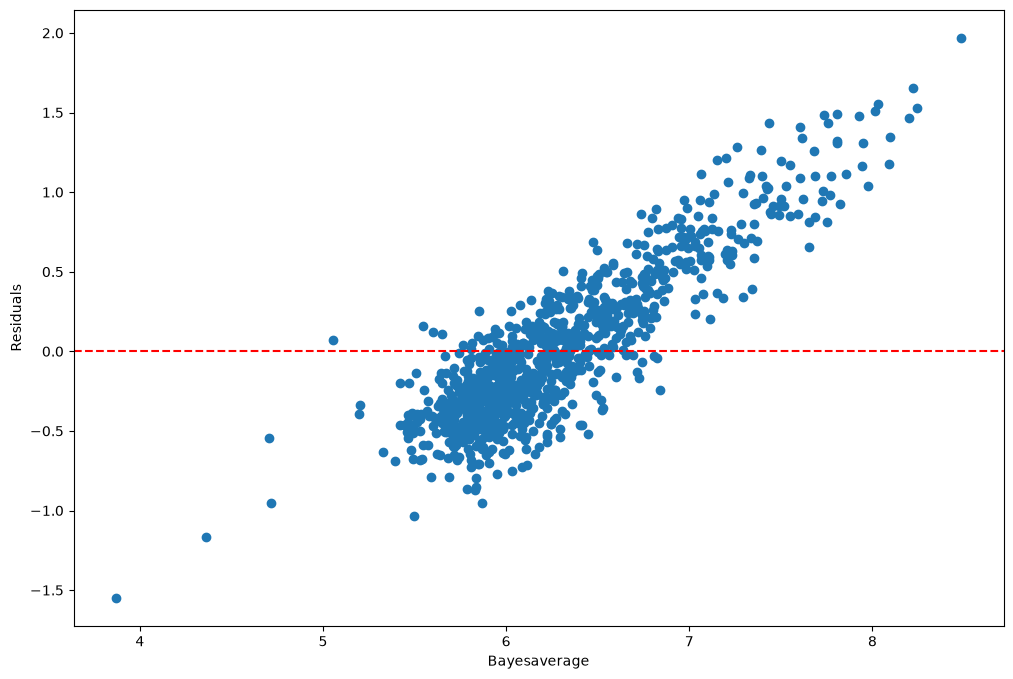

In [250]:
plt.figure(figsize=(12,8))
plt.scatter(y_test, residuen)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Bayesaverage')
plt.ylabel('Residuals')
plt.show();


In [251]:
df_results = pd.DataFrame([lm_results, lasso_results, rf_results, lasso_optimized_results, rf_optimized_results])
df_results = df_results.sort_values('R_squared', ascending = False)
df_results.head()

,R_squared,MAE,RMSE,model
4,0.273571,0.373884,0.475571,RF_optimized
0,0.271826,0.374633,0.476142,LinearRegression
3,0.271333,0.374691,0.476303,Lasso_optimized
1,0.265363,0.375522,0.478250,Lasso
2,0.134476,0.409286,0.519108,RF


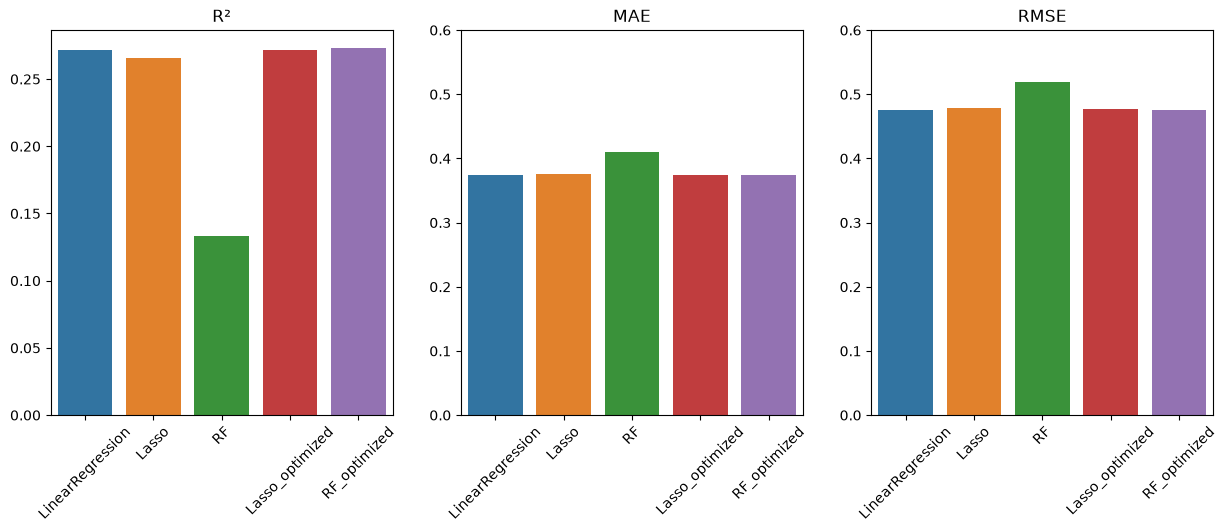

In [233]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data = df_results, x = 'model', y ='R_squared', hue = 'model',ax=axes[0])
sns.barplot(data = df_results, x = 'model', y ='MAE', hue = 'model',ax=axes[1])
sns.barplot(data = df_results, x = 'model', y ='RMSE', hue = 'model',ax=axes[2])
axes[1].sharey(axes[2])
axes[0].set_title('R²')
axes[1].set_title('MAE')
axes[2].set_title('RMSE')
plt.ylim(0, 0.6)
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')


plt.show();